# Interactive Exploration of CloudSat-ABI Fusion
This notebook breaks down `crop_abi_multitemporal.py` into executable chunks for debugging and understanding.

**Note:** Ensure your kernel is set to `cropTest` (or the environment where `pyhdf` and `netCDF4` are installed).

In [ ]:
import numpy as np
import pyhdf
from pyhdf.SD import SD, SDC
from pyhdf.HDF import *
from pyhdf.VS import *
import glob
import os
import netCDF4 as nc
import sys
import matplotlib.pyplot as plt

'''
CONFIGURATION PARAMETERS
'''
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
CLOUDSATPATH = '/home/al8425b-hpc/NASA/cropTest/testData/cloudsat/'
ROOT_DIR = '/home/al8425b-hpc/NASA/cropTest/testData/cloudsat/2B-CLDCLASS-LIDAR'
ABIDATA = "/home/al8425b-hpc/NASA/cropTest/testData/GOES_Data/" 
SAVEDIR = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output'

# Multi-timestep configuration
OFFSETS_MINUTES = [-40, -20, 0, 20, 40]
CHIP_HALF_SIZE = 64
ALLOW_MISSING_TIMESTEPS = False

In [ ]:
# Target a specific orbit for testing
test_year = "2020"
test_day = "001"
test_orbit = "72860" # Extracted from file names in 2B-CLDCLASS-LIDAR/2020/001/

### Core Utilities
Defining the readers and coordinate search logic from the main script.

In [ ]:
def read_2b_cldclass_lidar(cs_file, latbin=None):
    f_2b_cldclass_lidar = SD(cs_file, SDC.READ)
    cs_clb = f_2b_cldclass_lidar.select('CloudLayerBase').get()
    cs_clt = f_2b_cldclass_lidar.select('CloudLayerTop').get()
    cs_cltype = f_2b_cldclass_lidar.select('CloudLayerType').get()

    sdc_2bcldclass_lidar = HDF(cs_file, SDC.READ)
    vs_2bcldclass_lidar = sdc_2bcldclass_lidar.vstart()
    cs_QC = np.squeeze(vs_2bcldclass_lidar.attach('Data_quality')[:])
    Latitude = np.squeeze(vs_2bcldclass_lidar.attach('Latitude')[:])
    Longitude = np.squeeze(vs_2bcldclass_lidar.attach('Longitude')[:])

    ilat = np.squeeze(np.argwhere((Latitude >= latbin[0]) & (Latitude <= latbin[1])))
    return (cs_clb[ilat, :], cs_clt[ilat, :], cs_cltype[ilat, :], cs_QC[ilat], Latitude[ilat], Longitude[ilat])

def read_cs_ecmwf(aux_file, latbin=None):
    f_ecmwf = SD(aux_file, SDC.READ)
    Pressure = f_ecmwf.select('Pressure').get()
    Temperature = f_ecmwf.select('Temperature').get()
    Specific_humidity = f_ecmwf.select('Specific_humidity').get()

    sdc_ecmwf = HDF(aux_file, SDC.READ)
    vs_ecmwf = sdc_ecmwf.vstart()
    EC_height = np.squeeze(vs_ecmwf.attach('EC_height')[:])
    Profile_time = np.squeeze(vs_ecmwf.attach('Profile_time')[:])
    UTC_start = np.squeeze(vs_ecmwf.attach('UTC_start')[:])
    Latitude = np.squeeze(vs_ecmwf.attach('Latitude')[:])
    Longitude = np.squeeze(vs_ecmwf.attach('Longitude')[:])
    Temperature_2m = np.squeeze(vs_ecmwf.attach('Temperature_2m')[:])
    
    UTC_Time = (UTC_start + Profile_time) / 3600.0

    ilat = np.squeeze(np.argwhere((Latitude >= latbin[0]) & (Latitude <= latbin[1])))
    return (Pressure[ilat, :], Temperature[ilat, :], Specific_humidity[ilat, :], EC_height, Temperature_2m[ilat], UTC_Time[ilat])

In [ ]:
print("Loading ABI Lat/Lon grid (this may take a moment)...")
f = nc.Dataset(LATLONDATA)
abiLong = np.array(f['Longitude'])
abiLat = np.array(f['Latitude'])

BOUND_SIZE = 1600
LENGTH = 10848
abiLongB = abiLong[BOUND_SIZE:LENGTH-BOUND_SIZE, BOUND_SIZE:LENGTH-BOUND_SIZE]
abiLatB = abiLat[BOUND_SIZE:LENGTH-BOUND_SIZE, BOUND_SIZE:LENGTH-BOUND_SIZE]
abiLongB[abiLongB == -999] = 10
abiLatB[abiLatB == -999] = 10
abiLongB[abiLongB < 0] += 360

latMin, latMax = abiLatB.min(), abiLatB.max()
longMin, longMax = abiLongB.min(), abiLongB.max()
print(f"ABI Bounds: Lat({latMin:.2f}, {latMax:.2f}), Lon({longMin:.2f}, {longMax:.2f})")

Loading ABI Lat/Lon grid (this may take a moment)...
ABI Bounds: Lat(-43.66, 43.66), Lon(212.60, 357.40)


In [ ]:
cs_files = glob.glob(os.path.join(CLOUDSATPATH, '2B-CLDCLASS-LIDAR', test_year, test_day, f"*{test_orbit}*2B-CLDCLASS-LIDAR*hdf"))
aux_files = glob.glob(os.path.join(CLOUDSATPATH, 'ECMWF-AUX', test_year, test_day, f"*{test_orbit}*ECMWF-AUX*hdf"))

if cs_files and aux_files:
    print(f"Found CloudSat: {os.path.basename(cs_files[0])}")
    print(f"Found ECMWF: {os.path.basename(aux_files[0])}")
    
    # Read Data
    cs_clb, cs_clt, cs_cltype, cs_QC, Latitude, Longitude = read_2b_cldclass_lidar(cs_files[0], latbin=(latMin, latMax))
    Pressure, Temperature, Specific_humidity, EC_height, Temperature_2m, UTC_Time = read_cs_ecmwf(aux_files[0], latbin=(latMin, latMax))
    
    # Fix longitude convention if needed
    Longitude[Longitude < 0] += 360
    
    print(f"Successfully read {len(Latitude)} track points.")
else:
    print("Files not found. Check test_orbit.")

Found CloudSat: 2020001002545_72860_CS_2B-CLDCLASS-LIDAR_GRANULE_P1_R05_E09_F00.hdf
Found ECMWF: 2020001002545_72860_CS_ECMWF-AUX_GRANULE_P1_R05_E09_F00.hdf
Successfully read 18081 track points.


### Visualize the CloudSat Track
Let's see where the satellite was flying and what temperatures it recorded.

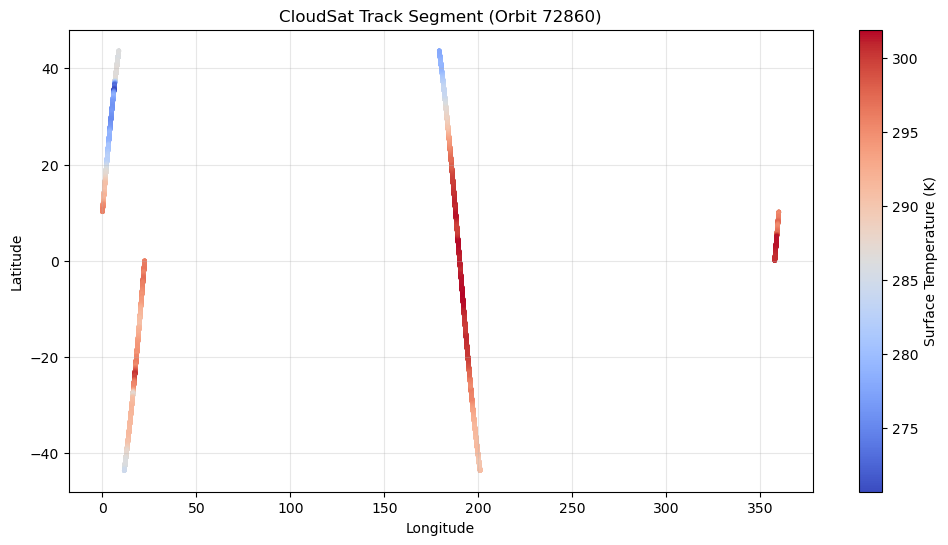

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(Longitude, Latitude, c=Temperature_2m, s=5, cmap='coolwarm')
plt.colorbar(label='Surface Temperature (K)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'CloudSat Track Segment (Orbit {test_orbit})')
plt.grid(True, alpha=0.3)
plt.show()

## Step 2: Mapping Track to ABI Pixels
Now that we have the CloudSat track, we need to find which pixels in the GOES-16 ABI image correspond to those (Lat, Lon) points.

In [7]:
latSlice = abiLat[:, 5424]
latSlice = latSlice[18:-18]
longSlice = abiLong[5424, :]
longSlice = longSlice[18:-18]
latSlice = latSlice[::-1]

def find_abi_coords(lat, lon):
    if lat < latMin or lat > latMax or lon < longMin or lon > longMax:
        raise ValueError(f"Point (Lat={lat:.2f}, Lon={lon:.2f}) is outside ABI box [Lat: {latMin:.2f}-{latMax:.2f}, Lon: {longMin:.2f}-{longMax:.2f}]")

    AREA_SIZE = 1000
    lati = len(latSlice) - np.searchsorted(latSlice, lat) + 17
    loni = np.searchsorted(longSlice, lon) + 18

    distances = (
        np.abs(abiLat[lati-AREA_SIZE:lati+AREA_SIZE, loni-AREA_SIZE:loni+AREA_SIZE] - lat) +
        np.abs(abiLong[lati-AREA_SIZE:lati+AREA_SIZE, loni-AREA_SIZE:loni+AREA_SIZE] - lon)
    )

    coords = np.array(np.unravel_index(distances.argmin(), distances.shape))
    coords[0] += lati - AREA_SIZE
    coords[1] += loni - AREA_SIZE
    return coords

if len(Latitude) > 0:
    sample_lat, sample_lon = Latitude[0], Longitude[0]
    print(f"Testing Point: Lat={sample_lat:.4f}, Lon={sample_lon:.4f}")
    
    try:
        sample_coords = find_abi_coords(sample_lat, sample_lon)
        print(f"Result: ABI Pixels (Y={sample_coords[0]}, X={sample_coords[1]})")
    except ValueError as e:
        print(f"❌ {e}")
else:
    print("No track points found in ABI bounds.")

Testing Point: Lat=-0.0053, Lon=22.4572
❌ Point (Lat=-0.01, Lon=22.46) is outside ABI box [Lat: -43.66-43.66, Lon: 212.60-357.40]
